# Linear Regression and Gradient Descent from Scratch

### A step-by-step implementation of SGD, Batch Gradient Descent, and Mini-batch Gradient Descent using Python

---

## Project overview

This notebook explores how a **simple linear regression model learns from data** by implementing Gradient Descent from scratch.

Instead of relying on a machine-learning library to train the model, every step is written explicitly:

- Generate predictions using a linear equation.
- Measure the prediction error.
- Update the slope and intercept.
- Repeat the learning process across multiple epochs.
- Compare different Gradient Descent strategies.
- Visualize the final regression lines and their error curves.

The purpose of this project is to develop an intuitive understanding of what happens internally during model training.

---

## Linear regression model

The model is represented by:

$$
\hat{y} = mx + b
$$

where:

- $m$ is the slope.
- $b$ is the intercept or bias.
- $x$ is the input variable.
- $\hat{y}$ is the predicted value.

The model learns the values of $m$ and $b$ by minimizing the **Mean Squared Error (MSE)**:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

---

## Gradient Descent methods

This notebook implements and compares three optimization strategies:

| Method | Data used per update | Main characteristic |
|---|---:|---|
| **Stochastic Gradient Descent** | One observation | Frequent but noisy updates |
| **Batch Gradient Descent** | Complete dataset | Stable but less frequent updates |
| **Mini-batch Gradient Descent** | Small group of observations | Balance between speed and stability |

---

## Technologies

- Python
- NumPy
- Matplotlib
- Jupyter Notebook

---

## Learning objectives

By the end of this notebook, you should be able to explain:

- How linear regression generates predictions.
- How prediction error changes the model parameters.
- The difference between parameters and hyperparameters.
- What an epoch represents.
- Why training observations are shuffled.
- How SGD, Batch, and Mini-batch Gradient Descent differ.
- Why stochastic error curves fluctuate during training.
- How the learning rate affects convergence.

---

> **Educational project:** The algorithms are intentionally implemented from scratch to make the training process transparent and easier to understand.

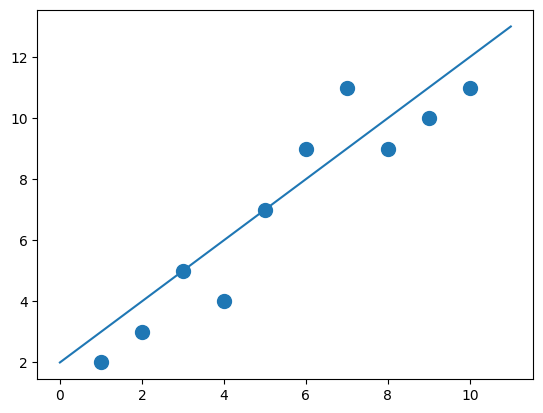

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output

# Generate random points
X = np.array([1, 2, 3, 4, 5,6,7,8,9,10])
y = np.array([2, 3, 5, 4, 7,9,11,9,10,11])
# X = X/10  # Normalize to make the effect of the learning rate on b more visible

plt.scatter(X,y, s = 100)

# Line
# Initial values
m = 1
b = 2
x_linea = np.linspace(0, 11, 100)
y_linea = m * x_linea + b
plt.plot(x_linea, y_linea)

### Evaluate and Fit Random Points

Now we need to do the following:

1. Randomly select points.

2. Calculate the error between the selected point and the prediction.

3. Move the line toward that point in steps determined by the learning rate.

4. Measure the error of all points relative to that line.

5. Repeat until the stopping condition is met; in this case, the number of iterations.

## Where do the updates for `m` and `b` come from?

We start with a straight line:

$$
\hat{y} = mx + b
$$

where:

- `m` = slope
- `b` = bias or intercept
- `x` = input value
- $\hat{y}$ = prediction

We define the error as:

$$
error = y - \hat{y} = y-mx-b
$$

---

## 1. Loss function

To measure how far the prediction is from the actual value, we use the squared error:

$$
L = error^2 = (y-mx-b)^2
$$

Squaring prevents positive and negative errors from canceling each other out.

---

## 2. Derivative with respect to `m`

We want to know how the loss $L$ changes when the slope `m` changes slightly.

Let:

$$
u=y-mx-b
$$

Then:

$$
L=u^2
$$

### Brief explanation of the chain rule

The **chain rule** is used when one function is inside another. The idea is:

$$
\boxed{\text{derivative of the outer function} \times \text{derivative of the inner function}}
$$

For example, if $f(x)=(3x+2)^2$, first differentiate the outside, $u^2 \rightarrow 2u$, and then the inside, $3x+2 \rightarrow 3$:

$$
f'(x)=2(3x+2)(3)
$$

In our case, the outside is $u^2$ and the inside is $u=y-mx-b$.

The derivative of $u^2$ is $2u$. Differentiating the inside with respect to $m$ gives:

$$
\frac{\partial y}{\partial m}=0, \qquad
\frac{\partial(-b)}{\partial m}=0, \qquad
\frac{\partial(-mx)}{\partial m}=-x
$$

Therefore:

$$
\frac{\partial u}{\partial m}=-x
$$

Applying the chain rule:

$$
\frac{\partial L}{\partial m}
=2(y-mx-b)(-x)
=-2x(y-mx-b)
$$

Since $error=y-mx-b$:

$$
\boxed{\frac{\partial L}{\partial m}=-2\,error\,x}
$$

The key idea is that we first differentiate the **outside**, $u^2 \rightarrow 2u$, and then the **inside**, $y-mx-b \rightarrow -x$.

---

## 3. Updating `m`

Gradient Descent updates a parameter by subtracting its derivative:

$$
m_{new}=m-learning\_rate\frac{\partial L}{\partial m}
$$

Substituting the derivative:

$$
m_{new}=m-learning\_rate(-2\,error\,x)
$$

The two negative signs become positive:

$$
\boxed{m_{new}=m+learning\_rate\cdot2\cdot error\cdot x}
$$

In Python:

```python
m = m + learning_rate * 2 * error * current_x
```

---

## 4. Derivative with respect to `b`

We follow the same process for `b`:

$$
L=(y-mx-b)^2
$$

The derivative of the outer part is still $2(y-mx-b)$, while the derivative of the inner part with respect to $b$ is $-1$:

$$
\frac{\partial(y-mx-b)}{\partial b}=-1
$$

Therefore:

$$
\boxed{\frac{\partial L}{\partial b}=-2\,error}
$$

Gradient Descent gives:

$$
\boxed{b_{new}=b+learning\_rate\cdot2\cdot error}
$$

In Python:

```python
b = b + learning_rate * 2 * error
```

---

## 5. Why does Gradient Descent subtract the derivative?

The derivative tells us **how the loss changes when a parameter changes**. The gradient points in the direction in which the function increases, so to reduce the error we move in the opposite direction:

$$
\boxed{\theta_{new}=\theta-learning\_rate\frac{\partial L}{\partial \theta}}
$$

Here, $\theta$ can represent any model parameter, such as `m` or `b`.

### If the derivative is positive

If $\frac{\partial L}{\partial m}=5$, increasing `m` increases the loss. Gradient Descent subtracts a positive value, so `m` decreases.

### If the derivative is negative

If $\frac{\partial L}{\partial m}=-5$, increasing `m` decreases the loss. Subtracting a negative value increases `m`.

### A simple way to remember it

$$
\boxed{\text{derivative = uphill direction}}
$$

$$
\boxed{-\text{derivative = downhill direction}}
$$

Gradient Descent searches for a **minimum of the loss function**, so it follows the negative gradient. Gradient Ascent does the opposite and adds the gradient to maximize a function.

---

## An intuitive way to understand the updates

```python
m = m + learning_rate * 2 * error * current_x
b = b + learning_rate * 2 * error
```

- `error` tells us **how much correction is needed**.
- `current_x` tells us **how strongly a slope change affects this point**.
- `learning_rate` determines **what fraction of the correction to apply**.
- The factor `2` comes from differentiating a squared error.

For the slope:

$$
\text{correction to }m=learning\_rate\times2\times error\times x
$$

For the bias:

$$
\text{correction to }b=learning\_rate\times2\times error
$$

### Key idea

**`b` moves the line up or down.**

**`m` changes the line's slope.**

Because `m` changes the slope, its effect depends on the point's position on the `x` axis. That is why `current_x` appears in the update for `m`.

The factor `2` appears naturally because:

$$
\frac{d}{d(error)}error^2=2\,error
$$

## 6. Numerical example of one iteration

Suppose we have a single point:

$$x=2$$

$$y=5$$

We start with:

$$m=1$$

$$b=0$$

and:

$$learning\_rate=0.1$$

---

### Step 1. Make the prediction

We use:

$$\hat y=mx+b$$

Substituting the values:

$$\hat y=(1)(2)+0$$

Therefore:

$$\boxed{\hat y=2}$$

---

### Step 2. Calculate the error

Recall that:

$$error=y-\hat y$$

Then:

$$error=5-2$$

Therefore:

$$\boxed{error=3}$$

The prediction is below the actual value.

---

### Step 3. Calculate the derivative with respect to `m`

We know that:

$$\frac{\partial L}{\partial m}=-2\,error\,x$$

Substituting:

$$\frac{\partial L}{\partial m}=-2(3)(2)$$

Therefore:

$$\boxed{\frac{\partial L}{\partial m}=-12}$$

The negative sign indicates that, at this point, increasing `m` helps reduce the loss.

---

### Step 4. Update `m`

Gradient Descent uses:

$$m_{new}=m-learning\_rate\frac{\partial L}{\partial m}$$

Substituting:

$$m_{new}=1-0.1(-12)=1+1.2$$

Therefore:

$$\boxed{m_{new}=2.2}$$

---

### Step 5. Calculate the derivative with respect to `b`

We know that:

$$\frac{\partial L}{\partial b}=-2\,error$$

Substituting:

$$\frac{\partial L}{\partial b}=-2(3)$$

Therefore:

$$\boxed{\frac{\partial L}{\partial b}=-6}$$

---

### Step 6. Update `b`

Gradient Descent uses:

$$b_{new}=b-learning\_rate\frac{\partial L}{\partial b}$$

Substituting:

$$b_{new}=0-0.1(-6)=0+0.6$$

Therefore:

$$\boxed{b_{new}=0.6}$$

---

## 7. Did the prediction improve?

Before the update:

$$m=1, \qquad b=0, \qquad \hat y=2$$

After the update:

$$m=2.2, \qquad b=0.6$$

Recalculating:

$$\hat y=mx+b=(2.2)(2)+0.6=5$$

In this particular example, one update takes us exactly to the actual value. The error changes from $5-2=3$ to $5-5=0$.

---

## 8. The same iteration in Python

```python
current_x = 2
actual_y = 5

m = 1
b = 0
learning_rate = 0.1

# Prediction
y_pred = m * current_x + b

# Error
error = actual_y - y_pred

# Update m
m = m + learning_rate * 2 * error * current_x

# Update b
b = b + learning_rate * 2 * error

print("Initial prediction:", y_pred)
print("Error:", error)
print("New m:", m)
print("New b:", b)

# New prediction
new_prediction = m * current_x + b
print("New prediction:", new_prediction)
```

Approximate result:

```text
Initial prediction: 2
Error: 3
New m: 2.2
New b: 0.6
New prediction: 5.0
```

---

## 9. What is really happening?

Each iteration follows these steps:

1. The model makes a prediction: $\hat y=mx+b$.
2. It calculates how far off the prediction is: $error=y-\hat y$.
3. The derivatives show how each parameter affects the loss.
4. Gradient Descent moves in the direction opposite to the gradient.
5. The parameters `m` and `b` are updated.
6. The prediction is calculated again.

This process repeats until the loss stops decreasing significantly:

$$
\boxed{
\text{predict}
\rightarrow
\text{measure error}
\rightarrow
\text{calculate derivatives}
\rightarrow
\text{correct parameters}
\rightarrow
\text{repeat}
}
$$

The derivative does not directly tell us the final value of `m` or `b`. It tells us:

> “From my current position, in which direction should I move this parameter to reduce the error?”

The `learning_rate` determines the size of that step.

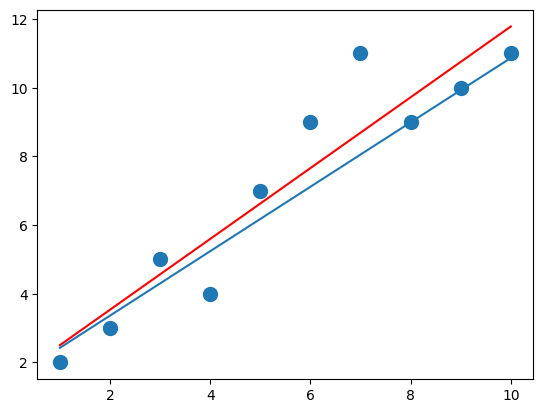

Lowest error: 1.2250463429318956
Best iteration: 461
Generated line: y = 0.938x + 1.488


In [2]:
learning_rate = 0.01
iterations = 500
total_errors = []
slopes = []
biases = []

random.seed(42)
for it in range(iterations):
    point_index = random.randrange(len(X))  # Random point

    current_x = X[point_index]  # Store the X coordinate
    actual_y = y[point_index]   # Get the actual y value

    y_pred = m * current_x + b  # Evaluate the line at the randomly selected point
    error = actual_y - y_pred   # Error between the selected point and the line

    # Adjust the slope and bias. The factor 2 is omitted for simplicity;
    # this scaling does not change the location of the minimum.
    m = m + learning_rate * error * current_x
    b = b + learning_rate * error

    predictions = m * X + b
    total_error = np.mean((y - predictions) ** 2)
    total_errors.append(total_error)
    slopes.append(m)
    biases.append(b)

    # Clear the previous output
    clear_output(wait=True)

    best_index = total_errors.index(min(total_errors))
    final_line = slopes[best_index] * X + biases[best_index]

    plt.scatter(X, y, s=100)
    plt.plot(X, predictions)
    plt.plot(X, final_line, color="red")
    plt.show()
    print("Lowest error:", min(total_errors))
    print("Best iteration:", best_index)
    print(f"Generated line: y = {m:0.3f}x + {b:0.3f}")
    time.sleep(0.1)

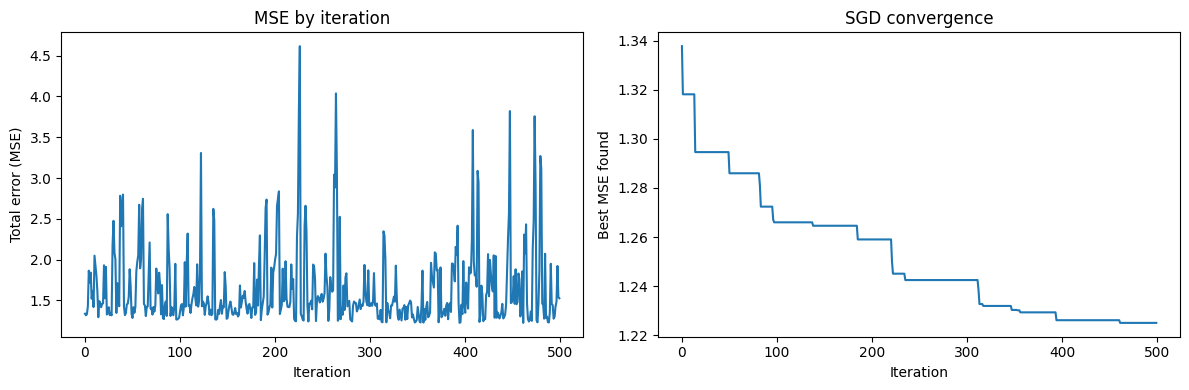

In [3]:
best_error_so_far = np.minimum.accumulate(total_errors)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: MSE by iteration
ax[0].plot(total_errors)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Total error (MSE)")
ax[0].set_title("MSE by iteration")

# Plot 2: best cumulative MSE
ax[1].plot(best_error_so_far)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Best MSE found")
ax[1].set_title("SGD convergence")

plt.tight_layout()
plt.show()

## Conclusion

This code implements a form of **Stochastic Gradient Descent (SGD)** for linear regression:

1. It randomly selects one data point.
2. It calculates the prediction for that point using $\hat{y}=mx+b$.
3. It calculates the error between the actual value and the prediction.
4. It updates `m` and `b` using the error from **only the selected point**.
5. It calculates the Mean Squared Error (MSE) across **all data points** to evaluate the overall performance of the line and keep track of the best solution found.
6. It repeats this process for a fixed number of iterations.

An important distinction is that each individual update does **not** minimize the error of all points simultaneously. Instead, it uses one randomly selected point at a time. However, after repeatedly sampling points and updating the parameters, the line tends to reduce the overall error across the complete dataset.

In short:

> **Each update learns from one random point, while the global MSE measures how well the resulting line fits all points.**

### 1. Stochastic Gradient Descent (SGD)

At the beginning of each epoch, the data indices are shuffled. The algorithm visits every point once in that shuffled order and updates the slope and bias immediately after each individual point. The error for the complete dataset is calculated at the end of the epoch only to monitor training.

In [4]:
# SGD: update the parameters using one point at a time
learning_rate = 0.01
epochs = 50
SGD_errors = []

m_SGD = 1
b_SGD = 2
random.seed(42)

for epoch in range(epochs):
    indices = list(range(len(X)))
    random.shuffle(indices) # Shuffle the points at the beginning of every epoch

    for point_index in indices:
        x_current = X[point_index]
        y_actual = y[point_index]
        y_pred = m_SGD * x_current + b_SGD
        error = y_actual - y_pred

        # Update the parameters using only the current point
        m_SGD = m_SGD + learning_rate * error * x_current
        b_SGD = b_SGD + learning_rate * error

    predictions = m_SGD * X + b_SGD
    total_error = np.mean((y - predictions) ** 2)
    SGD_errors.append(total_error)

print("Final SGD error:", SGD_errors[-1])
print(f"SGD line: y = {m_SGD:0.3f}x + {b_SGD:0.3f}")

Final SGD error: 1.8523896436048293
SGD line: y = 1.135x + 1.611


### 2. Batch Gradient Descent

Batch Gradient Descent calculates the adjustment using all data points before changing the slope and bias. Therefore, it performs only one parameter update per epoch. Its path is usually more stable, but each update becomes more expensive when the dataset is large.

In [5]:
# Batch Gradient Descent: update using all points
learning_rate = 0.01
epochs = 50
batch_errors = []

m_batch = 1
b_batch = 2

for epoch in range(epochs):
    # Make a prediction for every point
    predictions = m_batch * X + b_batch
    errors = y - predictions

    # Average the adjustments produced by all points
    m_adjustment = np.mean(errors * X)
    b_adjustment = np.mean(errors)

    # Perform only one update per epoch
    m_batch = m_batch + learning_rate * m_adjustment
    b_batch = b_batch + learning_rate * b_adjustment

    predictions = m_batch * X + b_batch
    total_error = np.mean((y - predictions) ** 2)
    batch_errors.append(total_error)

print("Final Batch error:", batch_errors[-1])
print(f"Batch line: y = {m_batch:0.3f}x + {b_batch:0.3f}")

Final Batch error: 1.2962647326578378
Batch line: y = 0.963x + 1.928


### 3. Mini-batch Gradient Descent

Mini-batch divides the shuffled data into small groups. The slope and bias are updated after each group, combining the frequent updates of SGD with a more stable estimate of the adjustment. This is the most common variant when training neural networks.

In [6]:
# Mini-batch: update using small groups of points
learning_rate = 0.01
epochs = 50
batch_size = 3
mini_batch_errors = []

m_mini_batch = 1
b_mini_batch = 2
random.seed(42)

for epoch in range(epochs):
    indices = list(range(len(X)))
    random.shuffle(indices) # Shuffle the points

    for start in range(0, len(X), batch_size):
        batch_indices = indices[start:start + batch_size]
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        batch_predictions = m_mini_batch * X_batch + b_mini_batch
        batch_errors_current = y_batch - batch_predictions

        # Average the adjustments produced by the points in the batch
        m_adjustment = np.mean(batch_errors_current * X_batch)
        b_adjustment = np.mean(batch_errors_current)

        m_mini_batch = m_mini_batch + learning_rate * m_adjustment
        b_mini_batch = b_mini_batch + learning_rate * b_adjustment

    predictions = m_mini_batch * X + b_mini_batch
    total_error = np.mean((y - predictions) ** 2)
    mini_batch_errors.append(total_error)

print("Final Mini-batch error:", mini_batch_errors[-1])
print(f"Mini-batch line: y = {m_mini_batch:0.3f}x + {b_mini_batch:0.3f}")

Final Mini-batch error: 2.0135940937087606
Mini-batch line: y = 1.126x + 1.766


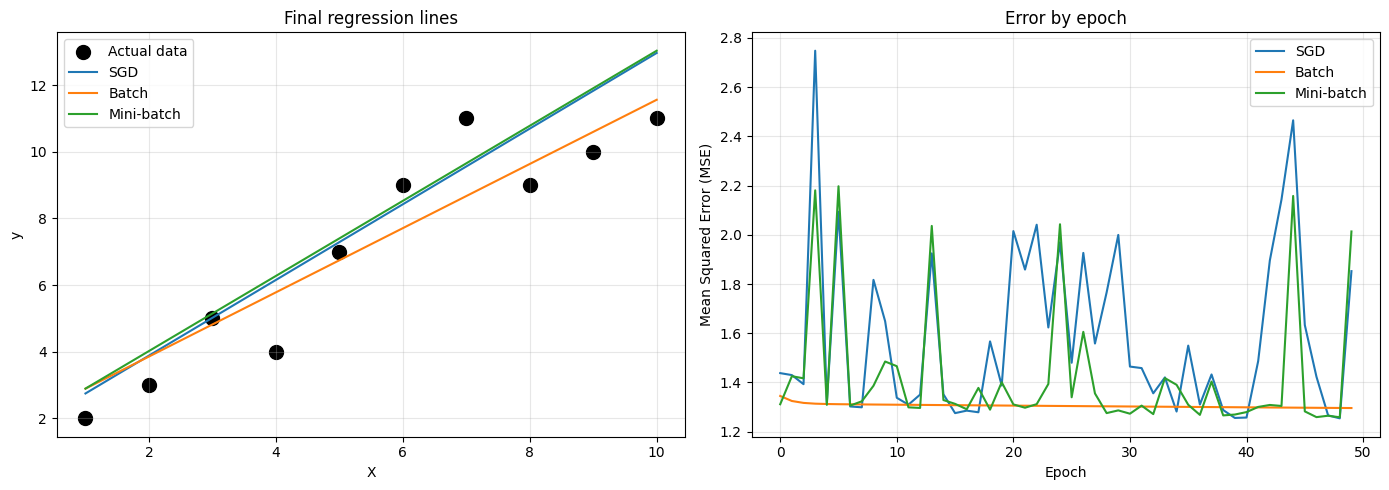

In [7]:
# Compare the final lines and the error curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Final lines
ax[0].scatter(X, y, s=100, color="black", label="Actual data")
ax[0].plot(X, m_SGD * X + b_SGD, label="SGD")
ax[0].plot(X, m_batch * X + b_batch, label="Batch")
ax[0].plot(X, m_mini_batch * X + b_mini_batch, label="Mini-batch")
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")
ax[0].set_title("Final regression lines")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Error curves
ax[1].plot(SGD_errors, label="SGD")
ax[1].plot(batch_errors, label="Batch")
ax[1].plot(mini_batch_errors, label="Mini-batch")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean Squared Error (MSE)")
ax[1].set_title("Error by epoch")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

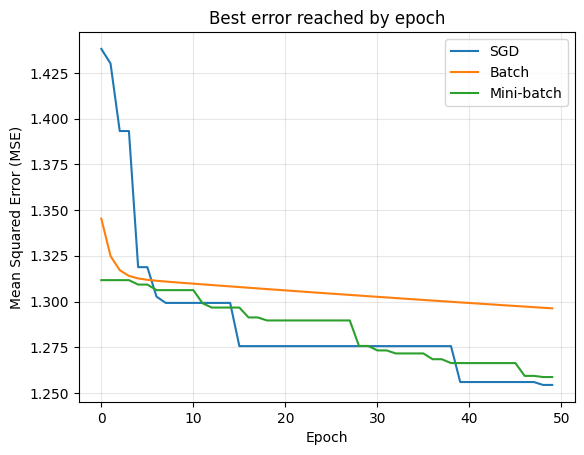

In [8]:
best_SGD_error = np.minimum.accumulate(SGD_errors)
best_mini_batch_error = np.minimum.accumulate(mini_batch_errors)

plt.plot(best_SGD_error, label="SGD")
plt.plot(batch_errors, label="Batch")
plt.plot(best_mini_batch_error, label="Mini-batch")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Best error reached by epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()